# **Problem Statement : Explore sales data to uncover patterns in customer behavior and identify ways to increase revenue and optimize business decisions**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("amazon_sales_dataset.csv")

In [ ]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [ ]:
df.shape

(50000, 13)

In [ ]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [ ]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [ ]:
df.dtypes

,0
order_id,int64
order_date,object
product_id,int64
product_category,object
price,float64
discount_percent,int64
quantity_sold,int64
customer_region,object
payment_method,object
rating,float64


Revenue by Category

Which product category generates highest revenue?

In [ ]:
df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).reset_index()

,product_category,total_revenue
0,Beauty,5550624.97
1,Books,5484863.03
2,Fashion,5480123.34
3,Home & Kitchen,5473132.55
4,Electronics,5470594.03
5,Sports,5407235.82


👉Insight

“Beauty category contributes highest revenue → key business driver”

Top Performing Products

Which products generate most revenue?

In [ ]:
df.groupby(['product_id','product_category'])['total_revenue'].sum().nlargest(10).reset_index()

,product_id,product_category,total_revenue
0,4781,Home & Kitchen,8640.37
1,3892,Beauty,8114.17
2,4069,Fashion,8088.71
3,3222,Sports,8087.70
4,3455,Fashion,7946.00
5,1980,Electronics,7916.53
6,4037,Home & Kitchen,7879.55
7,4184,Beauty,7714.78
8,4590,Fashion,7700.83
9,1329,Sports,7618.47


What is the overall distribution of payment methods used by our customers?

In [ ]:
payment_method=df['payment_method'].value_counts().reset_index().sort_values(by='payment_method',ascending=False)
payment_method.columns=['Payment Method','Count']
display(payment_method)

,Payment Method,Count
0,Wallet,10106
1,UPI,10078
2,Debit Card,9981
4,Credit Card,9908
3,Cash on Delivery,9927


What is the percentage breakdown of payment methods used across all transactions

In [ ]:
# Calculate the percentage breakdown of payment methods
payment_percentages = (df['payment_method'].value_counts(normalize=True) * 100).reset_index().sort_values(by='payment_method',ascending=False)

# Rename columns for a professional look
payment_percentages.columns = ['Payment Method', 'Percentage of Total (%)']

display(payment_percentages)

,Payment Method,Percentage of Total (%)
0,Wallet,20.212
1,UPI,20.156
2,Debit Card,19.962
4,Credit Card,19.816
3,Cash on Delivery,19.854


Which customer region generates the highest total revenue?

In [ ]:
df.groupby('customer_region')['total_revenue'].sum().reset_index()

,customer_region,total_revenue
0,Asia,8175199.83
1,Europe,8112311.57
2,Middle East,8301844.50
3,North America,8277217.84


What are the different product categories, and what is the overall proportion of sales among them?

In [ ]:
df.groupby('product_category')['quantity_sold'].sum().reset_index()

,product_category,quantity_sold
0,Beauty,25422
1,Books,25065
2,Electronics,24898
3,Fashion,25089
4,Home & Kitchen,24743
5,Sports,24753


What is the total revenue generated,and how many unique products were sold?

In [ ]:
total_revenue = df['total_revenue'].sum()
unique_products = df['product_id'].nunique()

print(f"Total revenue generated: {total_revenue}")
print(f"Number of unique products sold: {unique_products}")

Total revenue generated: 32866573.74
Number of unique products sold: 4000


How do sales fluctuate over time? Are there specific months or seasons that see a spike in total revenue or quantity sold?

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month').agg({
    'total_revenue': 'sum',
    'quantity_sold': 'sum'
}).reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)

display(monthly_sales)

,order_month,total_revenue,quantity_sold
0,2022-01,1419751.89,6498
1,2022-02,1266714.29,5662
2,2022-03,1392585.42,6455
3,2022-04,1371955.83,6178
4,2022-05,1374779.57,6235
5,2022-06,1352125.49,6143
6,2022-07,1346089.18,6245
7,2022-08,1449308.06,6479
8,2022-09,1403967.06,6385
9,2022-10,1334818.11,6207


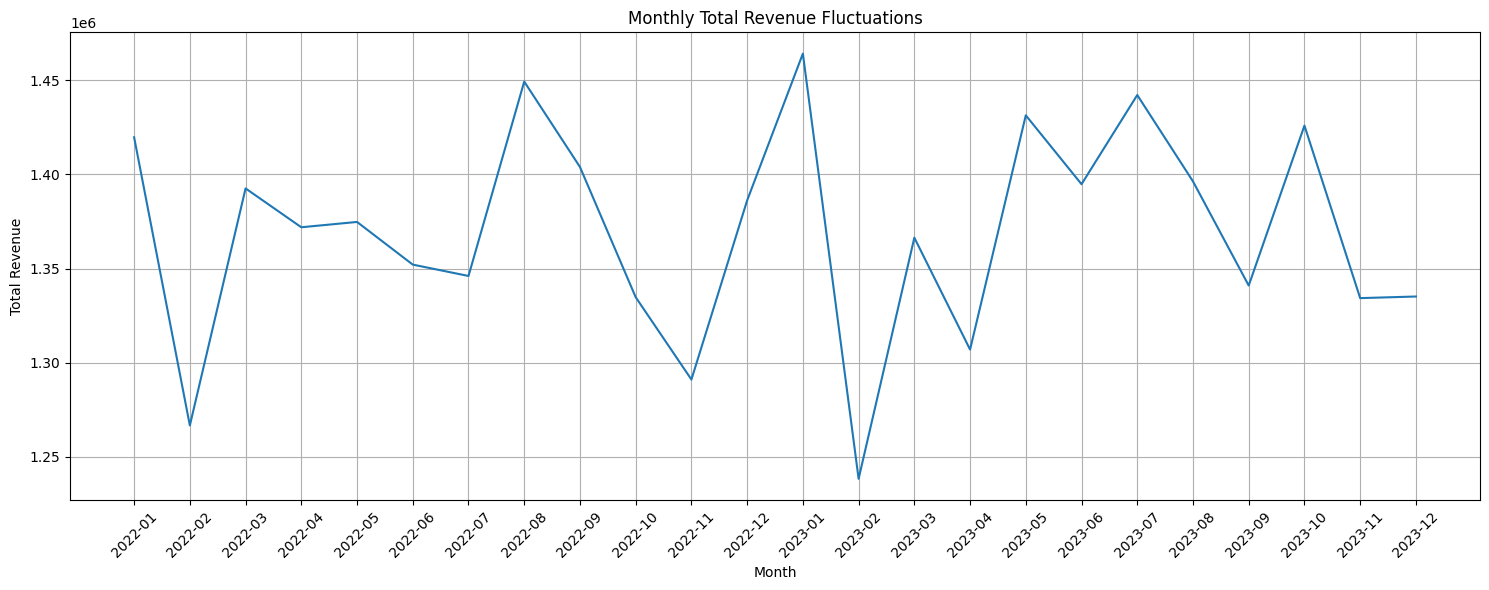

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.lineplot(x='order_month', y='total_revenue', data=monthly_sales)
plt.title('Monthly Total Revenue Fluctuations')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

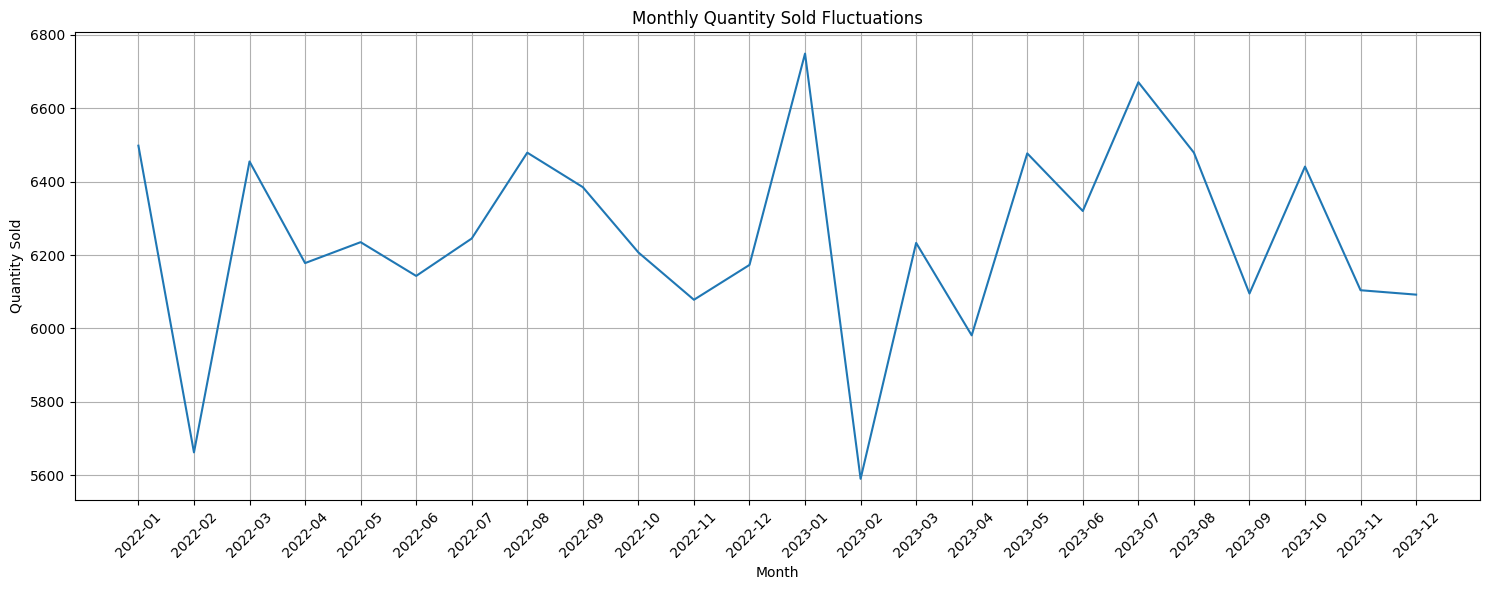

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='order_month', y='quantity_sold', data=monthly_sales)
plt.title('Monthly Quantity Sold Fluctuations')
plt.xlabel('Month')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

What is the complete ranking of payment methods—from most to least popular—within each individual customer region?

In [ ]:
payment_counts = df.groupby(['customer_region', 'payment_method']).size().reset_index(name='count').sort_values(['customer_region', 'count'], ascending=[True, False])
sorted_payments = payment_counts.sort_values(['customer_region', 'count'], ascending=[True, False])
display(sorted_payments)

,customer_region,payment_method,count
3,Asia,UPI,2606
4,Asia,Wallet,2496
0,Asia,Cash on Delivery,2487
1,Asia,Credit Card,2486
2,Asia,Debit Card,2451
7,Europe,Debit Card,2551
9,Europe,Wallet,2544
8,Europe,UPI,2478
6,Europe,Credit Card,2468
5,Europe,Cash on Delivery,2411


Do highly rated products (e.g., Rating > 4.5) actually sell in higher quantities than lower-rated products?

In [ ]:
df['rating_category'] = pd.cut(df['rating'], bins=[0, 4.5, 5], labels=['Low','High'])
rating_quantity = df.groupby('rating_category')['quantity_sold'].sum().reset_index()
display(rating_quantity)

,rating_category,quantity_sold
0,Low,133434
1,High,16536


Is there a correlation between the discount_percent and the quantity_sold? In other words, do heavier discounts actually drive people to buy more items?

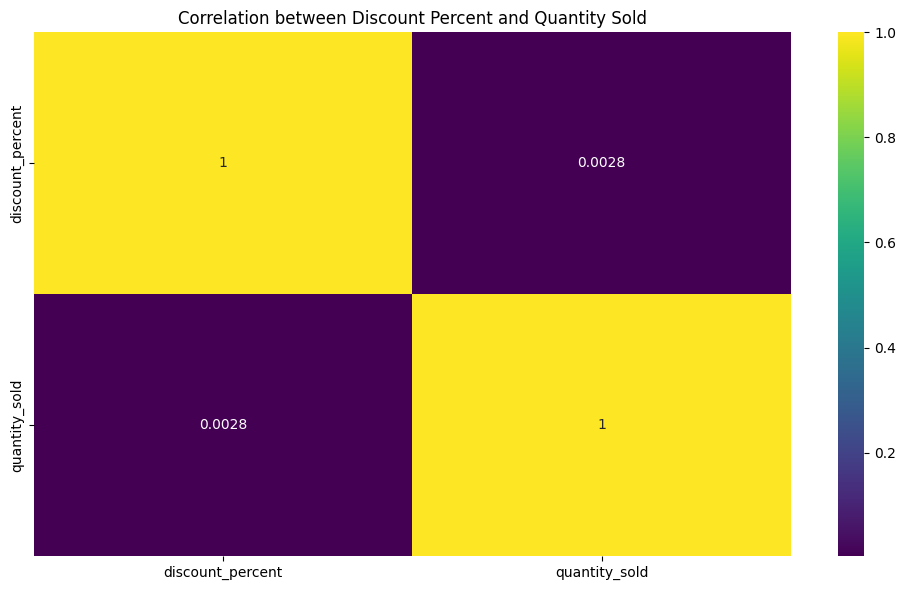

In [ ]:
plt.figure(figsize=(10,6))
df_subset = df[['discount_percent', 'quantity_sold']]
sns.heatmap(df_subset.corr(method='spearman'), annot=True, cmap="viridis")
plt.title('Correlation between Discount Percent and Quantity Sold')
plt.tight_layout()
plt.show()

How are the total sales distributed across different product categories within each customer region?

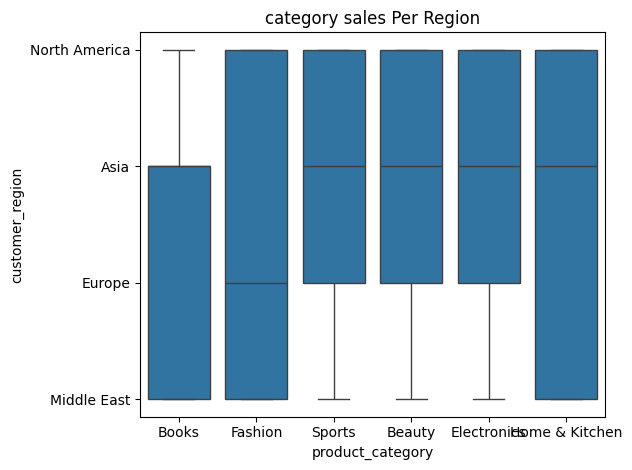

In [ ]:
sns.boxplot(x='product_category', y='customer_region', data=df)
plt.title('category sales Per Region')
plt.tight_layout()
plt.show()

What is the average discount percentage applied to each product category, and how does it compare to the total revenue generated by that category?

In [ ]:
category_discount_revenue = df.groupby('product_category').agg({
    'discount_percent': 'mean',
    'total_revenue': 'sum'
}).reset_index()

category_discount_revenue = category_discount_revenue.sort_values(by='discount_percent', ascending=False)
display(category_discount_revenue)

,product_category,discount_percent,total_revenue
5,Sports,13.406534,5407235.82
0,Beauty,13.371530,5550624.97
3,Fashion,13.358637,5480123.34
1,Books,13.337336,5484863.03
4,Home & Kitchen,13.311334,5473132.55
2,Electronics,13.258413,5470594.03


What is the Recency (days since last sale), Frequency (number of orders), and Monetary Value (total revenue) for every product in our inventory?

In [ ]:
# 1. Find the "current" date of the dataset
snapshot_date = df['order_date'].max()

# 2. Group by product and aggregate
product_rfm = df.groupby('product_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                  # Frequency
    'total_revenue': 'sum'                                  # Monetary
}).reset_index()

# 3. Rename columns so they look professional
product_rfm.columns = ['product_id', 'Recency_Days', 'Frequency', 'Monetary_Value']
display(product_rfm)

,product_id,Recency_Days,Frequency,Monetary_Value
0,1000,2,19,15717.10
1,1001,59,14,6199.10
2,1002,41,10,7648.22
3,1003,24,15,8938.15
4,1004,12,18,7069.71
...,...,...,...,...
3995,4995,80,16,8409.49
3996,4996,14,17,9996.84
3997,4997,112,8,6025.40
3998,4998,9,14,8528.61


Which top 10 products have gone the longest without being sold?

In [ ]:
Max_Date = df['order_date'].max()
df['days_since_last_sale'] = (Max_Date-df['order_date']).dt.days
df_max_days = df.groupby(['product_id','product_category'])['days_since_last_sale'].max().reset_index()
display(df_max_days.head(10))

,product_id,product_category,days_since_last_sale
0,1000,Beauty,389
1,1000,Books,569
2,1000,Electronics,270
3,1000,Fashion,697
4,1000,Home & Kitchen,707
5,1000,Sports,585
6,1001,Beauty,670
7,1001,Books,614
8,1001,Electronics,228
9,1001,Fashion,662


Which products are purchased most frequently (i.e., appear in the highest number of distinct orders)?

In [ ]:
Highest_purchases = df.groupby('product_id')['order_id'].nunique().reset_index()

# Rename the column so it's clear what the number means
Highest_purchases.columns = ['product_id', 'frequency_count']

# Sort to find the highest frequency at the top
top_frequent = Highest_purchases.sort_values(by='frequency_count', ascending=False).head(10)

display(top_frequent)

,product_id,frequency_count
3256,4256,27
3204,4204,26
580,1580,26
386,1386,25
3796,4796,25
1778,2778,24
2144,3144,23
3572,4572,23
3575,4575,23
766,1766,23


Which 5 products have generated the absolute highest total_revenue?

In [ ]:

Highest_revenue = df.groupby('product_id')['total_revenue'].sum().reset_index()

# Sort by total_revenue in descending order before taking the head(5)
top_5_revenue = Highest_revenue.sort_values(by='total_revenue', ascending=False).head(5)

display(top_5_revenue)

,product_id,total_revenue
931,1931,18885.83
87,1087,18531.52
328,1328,18306.73
2537,3537,18071.02
1837,2837,17855.07


Month-over-Month Revenue Growth

In [ ]:
# 1. Ensure order_date is a datetime object
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Group by Year-Month and sum the total_revenue
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum().reset_index()
monthly_revenue.columns = ['month', 'total_revenue']

# 3. Sort chronologically (CRITICAL step before calculating growth)
monthly_revenue = monthly_revenue.sort_values('month')

# 4. Calculate MoM Growth Percentage
monthly_revenue['mom_growth_%'] = monthly_revenue['total_revenue'].pct_change() * 100

display(monthly_revenue)

,month,total_revenue,mom_growth_%
0,2022-01,1419751.89,NaN
1,2022-02,1266714.29,-10.779179
2,2022-03,1392585.42,9.936821
3,2022-04,1371955.83,-1.481388
4,2022-05,1374779.57,0.205819
5,2022-06,1352125.49,-1.647834
6,2022-07,1346089.18,-0.446431
7,2022-08,1449308.06,7.668057
8,2022-09,1403967.06,-3.128458
9,2022-10,1334818.11,-4.925254


Year-over-Year Revenue Growth

In [ ]:
# 1. Ensure order_date is a datetime object
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Group by Year-Month and sum the total_revenue
monthly_revenue = df.groupby(df['order_date'].dt.to_period('Y'))['total_revenue'].sum().reset_index()
monthly_revenue.columns = ['month', 'total_revenue']

# 3. Sort chronologically (CRITICAL step before calculating growth)
monthly_revenue = monthly_revenue.sort_values('month')

# 4. Calculate MoM Growth Percentage
monthly_revenue['mom_growth_%'] = monthly_revenue['total_revenue'].pct_change() * 100

display(monthly_revenue)

,month,total_revenue,mom_growth_%
0,2022,16389404.56,NaN
1,2023,16477169.18,0.535496


# **BUSINESS INSIGHTS**

1. Discounts have a strong impact on customer purchasing behavior, indicating that customers are price-sensitive.

2. Products with higher ratings and more reviews tend to perform better, showing that customer trust plays a key role in driving sales.

3. A small number of products contribute to a large portion of total revenue, highlighting a dependency on top-performing products.

4. There is a significant difference between actual price and discounted price for many products, suggesting that pricing strategy influences customer perception.

5. Performance varies across product categories, with some categories consistently generating higher sales than others.

6. Products with a higher number of reviews often perform better than those with fewer reviews, even if ratings are similar.

7. Customers prefer products that offer a balance of good ratings, reasonable pricing, and attractive discounts.

8. High sales volume does not always translate into high revenue, indicating differences in product pricing and value contribution.

## **BUSINESS RECOMMENDATIONS**

1. Implement targeted discount strategies instead of applying uniform discounts across all products to optimize profitability.

2. Focus on improving product quality and encourage customer reviews to increase ratings and build trust.

3. Prioritize marketing and inventory management for top-performing products to maximize revenue.

4. Use strategic pricing techniques to enhance perceived value without heavily relying on deep discounts.

5. Allocate more resources to high-performing categories while improving strategies for underperforming categories.

6. Encourage customers to leave reviews through follow-ups or incentives to increase product credibility.

7. Position products as value-for-money by balancing pricing, quality, and discounts.

8. Focus on high-margin products in addition to high-volume products to improve overall profitability.
